# LSTM Stock Price Prediction

- LSTM -> Long Short Term Memory

## Requirements

In [401]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from torch.utils.data import Dataset
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler


## Tutorials
- **(Greg Hogg, 2023)** Video: https://www.youtube.com/watch?v=q_HS4s1L8UI&t=147s
- **(NeuralNine, 2025)** Video: https://www.youtube.com/watch?v=IJ50ew8wi-0

## Load Data

In [402]:
df = pd.read_csv('../data/combined_output.csv')

df.head()

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,...,3_day_max,3_day_min,5_day_max,5_day_min,day_of_week,numerical_sentiment,mean_sentiment_probability,percent_positive,percent_negative,percent_neutral
0,2026-01-26,672.36,675.2800,661.2855,665.125,16327378,671.797893,674.715452,660.732652,664.568942,...,675.2800,661.2855,675.2800,644.4450,1,-0.082474,0.797085,0.134021,0.216495,0.649485
1,2026-01-27,672.97,676.8150,664.6600,674.590,13148719,672.407383,676.249169,664.104331,674.026029,...,676.8150,661.2855,676.8150,644.4450,2,0.158879,0.790941,0.299065,0.140187,0.560748
2,2026-01-28,668.73,677.6775,666.1000,674.500,25709600,668.170928,677.110948,665.543127,673.936104,...,677.6775,661.2855,677.6775,661.2855,3,0.170543,0.801010,0.302326,0.131783,0.565891
3,2026-01-29,738.31,744.0000,712.5500,737.430,59852903,737.692758,743.378001,711.954294,736.813493,...,744.0000,664.6600,744.0000,661.2855,4,-0.027027,0.806134,0.209459,0.236486,0.554054
4,2026-01-30,716.50,732.1700,713.5900,727.500,23744573,715.900991,731.557891,712.993424,726.891795,...,744.0000,666.1000,744.0000,661.2855,5,-0.109375,0.837781,0.156250,0.265625,0.578125


## Check Device

In [403]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu:1'

device

'cpu:1'

## Lag Features

In [404]:
columns = df.columns

day = 1

df = df.set_index('date')

df['previous_day_numerical_sentiment'] = df['numerical_sentiment'].shift(day)
df['previous_day_mean_sentiment_probability'] = df['mean_sentiment_probability'].shift(day)
df['previous_day_percent_positive'] = df['percent_positive'].shift(day)
df['previous_day_percent_negative'] = df['percent_negative'].shift(day)
df['previous_day_percent_neutral'] = df['percent_neutral'].shift(day)

df = df.drop(columns=['high',
                      'low',
                      'open',
                      'volume',
                      'adjClose',
                      'adjHigh',
                      'adjLow',
                      'adjOpen',
                      'adjVolume',
                      'divCash',
                      'splitFactor',
                      'numerical_sentiment',
                      'mean_sentiment_probability',
                      'percent_positive',
                      'percent_negative',
                      'percent_neutral',])

df.iloc[2]

close                                      6.687300e+02
previous_day_close                         6.729700e+02
previous_day_high                          6.768150e+02
previous_day_low                           6.646600e+02
previous_day_open                          6.745900e+02
previous_day_volume                        1.314872e+07
1_day_max                                  6.776775e+02
1_day_min                                  6.661000e+02
3_day_max                                  6.776775e+02
3_day_min                                  6.612855e+02
5_day_max                                  6.776775e+02
5_day_min                                  6.612855e+02
day_of_week                                3.000000e+00
previous_day_numerical_sentiment           1.588785e-01
previous_day_mean_sentiment_probability    7.909406e-01
previous_day_percent_positive              2.990654e-01
previous_day_percent_negative              1.401869e-01
previous_day_percent_neutral               5.607

## Plot

[Text(0.5, 0, 'Date'), Text(0, 0.5, 'Closing Price')]

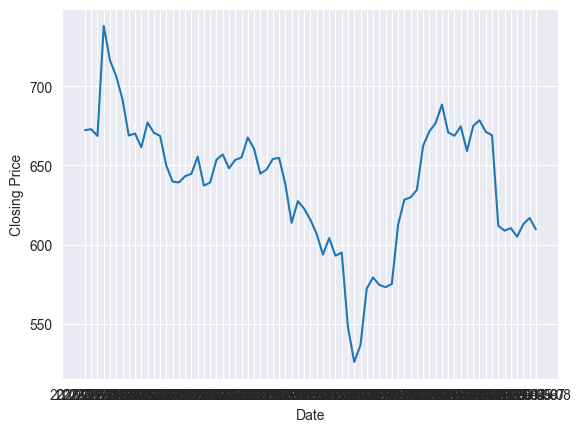

In [405]:
line_graph = sns.lineplot(x='date', y='close', data=df)
line_graph.set(xlabel='Date', ylabel='Closing Price')

## Remove Rows With Nulls

In [406]:
df = df.dropna()

## Scale Data

In [407]:
scalar_x = StandardScaler()
scalar_y = StandardScaler()

X_df = df.iloc[:,1:]
Y_df = df.iloc[:, [0]]

train_size = int(len(df) * 0.8)

X_train_df_as_numpy = scalar_x.fit_transform(X_df[:train_size]) # Fit to training data
X_test_df_as_numpy = scalar_x.transform(X_df[train_size:])
Y_train_df_as_numpy = scalar_y.fit_transform(Y_df[:train_size]) # Don't fit to test data as it will cause data leakage
Y_test_df_as_numpy = scalar_y.transform(Y_df[train_size:])


X_train_df_as_numpy

array([[ 8.24323025e-01,  6.88157910e-01,  7.87740113e-01,
         6.43328923e-01,  2.47673734e-02,  7.13583037e-01,
         8.58464930e-01,  5.60957159e-01,  1.02305860e+00,
         4.72653746e-01,  7.06134466e-01, -7.52218219e-01,
        -4.79290990e-01, -5.30371889e-01, -8.32681591e-01,
         5.67713494e-02,  5.49541650e-01],
       [ 8.38765158e-01,  7.24555866e-01,  8.69090843e-01,
         8.69054883e-01, -3.49166190e-01,  7.33914507e-01,
         8.92987871e-01,  5.81894794e-01,  1.02305860e+00,
         4.93762594e-01,  1.11099962e+00, -2.54989227e-02,
         1.30976928e+00, -8.35647900e-01,  1.48413867e+00,
        -7.54429005e-01, -3.53876255e-01],
       [ 7.38380499e-01,  7.45007487e-01,  9.03805631e-01,
         8.66908519e-01,  1.12848051e+00,  2.29731613e+00,
         2.00659248e+00,  2.19190790e+00,  1.10547418e+00,
         2.11694125e+00,  1.11099962e+00,  7.01220374e-01,
         1.39623125e+00, -3.35351847e-01,  1.52990325e+00,
        -8.43768391e-01, -3.0

## Split Data Train/Test

In [408]:
X_train = X_train_df_as_numpy.reshape((-1, 17, 1))
Y_train = Y_train_df_as_numpy.reshape((-1, 1))

X_test = X_test_df_as_numpy.reshape((-1, 17, 1))
Y_test = Y_test_df_as_numpy.reshape((-1, 1))

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((57, 17, 1), (57, 1), (15, 17, 1), (15, 1))

## Convert To Tensors

In [409]:
X_train = torch.tensor(X_train).float()
Y_train = torch.tensor(Y_train).float()
X_test = torch.tensor(X_test).float()
Y_test = torch.tensor(Y_test).float()

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

(torch.Size([57, 17, 1]),
 torch.Size([57, 1]),
 torch.Size([15, 17, 1]),
 torch.Size([15, 1]))

## Dataset Class

In [410]:
class StockDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [411]:
train_dataset = StockDataset(X_train, Y_train)
test_dataset = StockDataset(X_test, Y_test)

train_dataset.__len__()

57

## Dataloaders

In [412]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=False,
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
)

train_dataloader

In [413]:
for _, batch in enumerate(train_dataloader):
    x_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(x_batch.shape, y_batch.shape)


torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([4, 17, 1]) torch.Size([4, 1])
torch.Size([1, 17, 1]) torch.Size([1, 1])


## Define Neural Network

In [414]:
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size = x.shape[0]
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [415]:
model = Net(1, 32, 2, 1)
model.to(device)
model

Net(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

## Training Loop

In [416]:
lr = 1e-3
num_epochs = 500
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

for epoch in range(num_epochs):
    optimizer.zero_grad()
    output = model(X_train)
    loss = loss_function(output, Y_train)

    if epoch % 25 == 0:
        # Every 25 epochs
        print(epoch, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



0 1.006065011024475
25 0.6637088656425476
50 0.21630220115184784
75 0.16110019385814667
100 0.11664626002311707
125 0.10445847362279892
150 0.09636086970567703
175 0.07747787982225418
200 0.05355200543999672
225 0.04193444922566414
250 0.03466499596834183
275 0.029736388474702835
300 0.02532789297401905
325 0.022095292806625366
350 0.017827898263931274
375 0.014632356353104115
400 0.01265173964202404
425 0.011613809503614902
450 0.010916740633547306
475 0.009831215254962444


## Testing

In [417]:
model.eval()

test_output_prediction = model(X_test)

train_output_prediction = scalar_y.inverse_transform(output.detach().cpu().numpy())
train_actual = scalar_y.inverse_transform(Y_train.detach().cpu().numpy())
test_output_prediction = scalar_y.inverse_transform(test_output_prediction.detach().cpu().numpy())
test_actual = scalar_y.inverse_transform(Y_test.detach().cpu().numpy())

train_output_prediction.shape, train_actual.shape, test_output_prediction.shape, test_actual.shape

((57, 1), (57, 1), (15, 1), (15, 1))

In [418]:
train_rmse = root_mean_squared_error(train_actual, train_output_prediction)
test_rmse = root_mean_squared_error(test_actual, test_output_prediction)


In [419]:
{'train_rmse' :train_rmse, 'test_rmse':test_rmse}

{'train_rmse': 4.166924476623535, 'test_rmse': 11.48038387298584}